# Risk parity: equal capital is not equal risk

Equal dollars, inverse volatility and equal risk contributions are different portfolio decisions. This illustration uses constructed annual covariance assumptions; the accompanying ETF study separately tests their historical behavior.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/allocation.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.figsize': (9, 4.8), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18})

## Inputs and portfolio weights

The same covariance is supplied to every rule. ERC uses the maintained research implementation; the notebook reconstructs risk contributions directly from the resulting weights.

In [2]:
from research.allocation import erc, inverse_vol
names = ['Equities', 'Long bonds', 'Short bonds']
vol = np.array([0.18, 0.08, 0.04])
corr = np.array([[1, 0.20, 0.10], [0.20, 1, 0.60], [0.10, 0.60, 1]])
cov = np.outer(vol, vol) * corr
assert np.linalg.eigvalsh(cov).min() > 0
weights = pd.DataFrame({'Equal weight': np.full(3, 1/3), 'Inverse volatility': inverse_vol(cov), 'ERC': erc(cov)}, index=names)
risk = pd.DataFrame({name: w.to_numpy()*(cov @ w.to_numpy())/(w.to_numpy() @ cov @ w.to_numpy()) for name, w in weights.items()}, index=names)
display(weights.style.format('{:.2%}'))
display(risk.style.format('{:.2%}'))

,Equal weight,Inverse volatility,ERC
Equities,33.33%,12.90%,14.90%
Long bonds,33.33%,29.03%,27.34%
Short bonds,33.33%,58.06%,57.76%


,Equal weight,Inverse volatility,ERC
Equities,69.98%,27.08%,33.33%
Long bonds,21.77%,37.50%,33.33%
Short bonds,8.24%,35.42%,33.33%


## Capital budgets and risk budgets

A higher covariance between the two bond exposures changes ERC relative to inverse volatility. The risk-share panel shows what is being equalized.

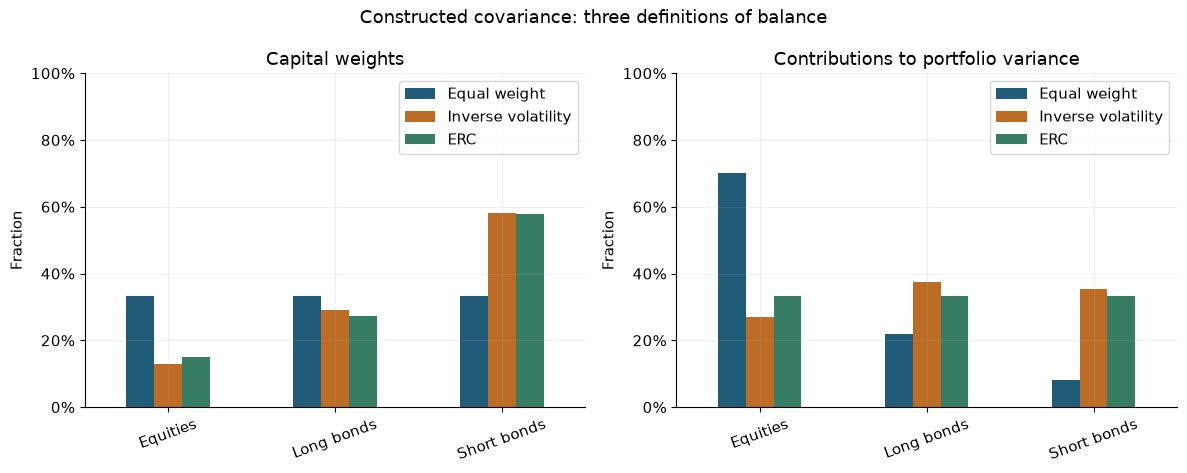

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
weights.plot.bar(ax=axes[0], rot=20, color=['#205b78','#bc6c25','#367d63'])
risk.plot.bar(ax=axes[1], rot=20, color=['#205b78','#bc6c25','#367d63'])
for ax, title in zip(axes, ['Capital weights', 'Contributions to portfolio variance']):
    ax.set(title=title, ylabel='Fraction', ylim=(0, 1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle('Constructed covariance: three definitions of balance'); fig.tight_layout(); plt.show()

## Checks from the decomposition

Risk shares must add to one, while volatility contributions must add to portfolio volatility. Independent assets provide a known case in which ERC equals inverse volatility.

In [4]:
np.testing.assert_allclose(weights.sum(), 1, atol=1e-9)
np.testing.assert_allclose(risk.sum(), 1, atol=1e-9)
np.testing.assert_allclose(risk['ERC'], np.full(3, 1/3), atol=1e-5)
np.testing.assert_allclose(erc(np.diag(vol**2)), inverse_vol(np.diag(vol**2)), atol=1e-5)
for name, w in weights.items():
    w = w.to_numpy(); portfolio_vol = np.sqrt(w @ cov @ w)
    np.testing.assert_allclose((w*(cov @ w)/portfolio_vol).sum(), portfolio_vol)
print('Budget, Euler decomposition, equal risk shares and independent-asset case: passed.')

Budget, Euler decomposition, equal risk shares and independent-asset case: passed.


## Research interpretation

ERC balances a model of variance. It does not establish balanced economic exposures or superior returns. Compare the observed holdings and cash treatment in the [full ETF study](../../study.ipynb), and use the [research note](README.md) for definitions and primary attribution.